#### [HMDA dataset](https://ffiec.cfpb.gov/data-browser/data/2022?category=counties&items=47037)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

##### Read in the data

In [2]:
# read in the data
hmda_2022 = pd.read_csv('../data/msamd_12060_2022.csv') 
hmda_2023 = pd.read_csv('../data/msamd_12060_2023.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2718690324.py:2: DtypeWarning: Columns (22,23,24,26,27,28,29,30,31,32,33,38,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_2022 = pd.read_csv('../data/msamd_12060_2022.csv')
C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2718690324.py:3: DtypeWarning: Columns (22,23,24,26,27,28,29,30,31,32,33,38,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_2023 = pd.read_csv('../data/msamd_12060_2023.csv')


In [3]:
hmda_2022.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2022,549300FGXN1K3HLB1R50,12060,GA,13135.0,1.313505e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4582,90.27,95700,59.25,693,1364,26
1,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5777,67.49,95700,117.88,1806,2070,29


In [4]:
len(hmda_2022.columns)

99

In [5]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022[hmda_2022.columns[0]].count()

np.int64(378284)

##### Remove all values that do not reflect approved and accepted = 1, or denied = 3

In [6]:
# remove all values that do not reflect approved, denied, or approved but not accepted
# Description: The action taken on the covered loan or application
# Values:
# 1 - Loan originated
# 2 - Application approved but not accepted
# 3 - Application denied
# 4 - Application withdrawn by applicant
# 5 - File closed for incompleteness
# 6 - Purchased loan
# 7 - Preapproval request denied
# 8 - Preapproval request approved but not accepted

list_of_values_to_keep = [1,3]

hmda_2022_action_taken = hmda_2022[hmda_2022['action_taken'].isin(list_of_values_to_keep)]
hmda_2022_action_taken['action_taken'].unique()

array([1, 3])

In [7]:
hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['action_taken']

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\203439602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['action_taken']


In [8]:
hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['approved_originated_or_denied'].replace({1 : 1, 3 : 0})

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\1368484208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['approved_originated_or_denied'].replace({1 : 1, 3 : 0})


In [9]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_action_taken[hmda_2022_action_taken.columns[0]].count()

np.int64(245118)

##### Remove not applicable (could include applicants with little to no credit and exempt institutions) to eliminate legal entities like corporations etc from being included in the data instead of individuals

In [10]:
# remove not applicable (could include applicants with little to no credit) and exempt institutions
# to eliminate legal entitities like corporations etc from being included in the data instead of individuals

# Description: The name and version of the credit scoring model used to generate the credit score, or scores, relied on in making the credit decision
# Values:
# 1 - Equifax Beacon 5.0
# 2 - Experian Fair Isaac
# 3 - FICO Risk Score Classic 04
# 4 - FICO Risk Score Classic 98
# 5 - VantageScore 2.0
# 6 - VantageScore 3.0
# 7 - More than one credit scoring model
# 8 - Other credit scoring model
# 9 - Not applicable
# 1111 - Exempt

list_of_values_to_keep = [1,2,3,4,5,6,7,8]

hmda_2022_credit_score_app = hmda_2022_action_taken[hmda_2022_action_taken['applicant_credit_score_type'].isin(list_of_values_to_keep)]
hmda_2022_credit_score_app['applicant_credit_score_type'].unique()

array([2, 1, 3, 8, 7, 6, 4, 5])

In [11]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_credit_score_app[hmda_2022_credit_score_app.columns[0]].count()

np.int64(214830)

##### Remove not applicable (could include applicants with little to no credit and exempt institutions) to eliminate legal entities like corporations etc from being included in the data instead of individuals`

In [12]:
# remove not applicable (could include applicants with little to no credit and exempt institutions)
# to eliminate legal entitities like corporations etc from being included in the data instead of individuals

# Description: The name and version of the credit scoring model used to generate the credit score, or scores, relied on in making the credit decision
# Values:
# 1 - Equifax Beacon 5.0
# 2 - Experian Fair Isaac
# 3 - FICO Risk Score Classic 04
# 4 - FICO Risk Score Classic 98
# 5 - VantageScore 2.0
# 6 - VantageScore 3.0
# 7 - More than one credit scoring model
# 8 - Other credit scoring model
# 9 - Not applicable
# 10 - No co-applicant
# 11 – FICO Score 9
# 12 – FICO Score 8
# 13 – FICO Score 10
# 14 – FICO Score 10T
# 15 - VantageScore 4.0
# 1111 - Exempt

list_of_values_to_keep = [1,2,3,4,5,6,7,8,10,11,12,13,14,15]

hmda_2022_credit_score_co = hmda_2022_credit_score_app[hmda_2022_credit_score_app['co-applicant_credit_score_type'].isin(list_of_values_to_keep)]
hmda_2022_credit_score_co['co-applicant_credit_score_type'].unique()

array([10,  3,  1,  2,  8,  6,  4,  7,  5, 11])

In [13]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_credit_score_co[hmda_2022_credit_score_co.columns[0]].count()

np.int64(174925)

##### Inspect all columns

In [14]:
# hmda_2022_credit_score_co.columns.tolist()

##### Create a unique index for each application/row

In [15]:
# create a unique number for every application as an ID column of sorts
hmda_2022_credit_score_co["unique_id"] = range(len(hmda_2022_credit_score_co))

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2598958234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co["unique_id"] = range(len(hmda_2022_credit_score_co))


##### Coerce to numeric the loan_to_value_ratio 

In [16]:
hmda_2022_credit_score_co['loan_to_value_ratio'].dtype
# hmda_ohe_dr['loan_to_value_ratio'].value_counts()
hmda_2022_credit_score_co['loan_to_value_ratio'] = pd.to_numeric(hmda_2022_credit_score_co['loan_to_value_ratio'], errors='coerce')
hmda_2022_credit_score_co['loan_to_value_ratio'].dtype
hmda_2022_credit_score_co['loan_to_value_ratio'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\3114287239.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['loan_to_value_ratio'] = pd.to_numeric(hmda_2022_credit_score_co['loan_to_value_ratio'], errors='coerce')


loan_to_value_ratio
80.000     17823
95.000     11122
96.500      9888
90.000      6193
100.000     6051
           ...  
70.126         1
60.928         1
58.984         1
81.997         1
81.060         1
Name: count, Length: 38100, dtype: int64

##### Make sure property_value is the correct data type

In [17]:
hmda_2022_credit_score_co['property_value'].dtype
hmda_2022_credit_score_co['property_value'] = pd.to_numeric(hmda_2022_credit_score_co['property_value'], errors='coerce')
hmda_2022_credit_score_co['property_value'].dtype
hmda_2022_credit_score_co['property_value'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\1753944827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['property_value'] = pd.to_numeric(hmda_2022_credit_score_co['property_value'], errors='coerce')


property_value
305000.0     6084
355000.0     5435
255000.0     5108
325000.0     4996
285000.0     4834
             ... 
6835000.0       1
4335000.0       1
2565000.0       1
6655000.0       1
2485000.0       1
Name: count, Length: 406, dtype: int64

##### Make sure income is the correct data type

In [18]:
hmda_2022_credit_score_co['income'].dtype

dtype('float64')

##### Make sure interest_rate is the correct data type

In [19]:
hmda_2022_credit_score_co['interest_rate'].dtype
hmda_2022_credit_score_co['interest_rate'] = pd.to_numeric(hmda_2022_credit_score_co['interest_rate'], errors='coerce')
hmda_2022_credit_score_co['interest_rate'].dtype
hmda_2022_credit_score_co['interest_rate'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\3821468937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['interest_rate'] = pd.to_numeric(hmda_2022_credit_score_co['interest_rate'], errors='coerce')


interest_rate
3.750    4534
3.875    4441
4.750    4421
5.250    4124
4.250    3952
         ... 
5.587       1
4.662       1
6.448       1
5.376       1
8.425       1
Name: count, Length: 2341, dtype: int64

##### Make sure rate_spread is the correct data type

In [20]:
hmda_2022_credit_score_co['rate_spread'].dtype
hmda_2022_credit_score_co['rate_spread'] = pd.to_numeric(hmda_2022_credit_score_co['rate_spread'], errors='coerce')
hmda_2022_credit_score_co['rate_spread'].dtype
hmda_2022_credit_score_co['rate_spread'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\101179261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['rate_spread'] = pd.to_numeric(hmda_2022_credit_score_co['rate_spread'], errors='coerce')


rate_spread
 0.0000    169
 0.1900    156
-0.0600    146
 0.3500    143
 0.1300    142
          ... 
 0.2614      1
 0.1858      1
 0.9694      1
 2.2912      1
 3.8780      1
Name: count, Length: 8661, dtype: int64

#### Filter down further for reverse mortgage

In [21]:
hmda_2022_credit_score_co['reverse_mortgage']

1         2
2         2
3         2
4         2
5         2
         ..
378279    2
378280    2
378281    2
378282    2
378283    2
Name: reverse_mortgage, Length: 174925, dtype: int64

In [22]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['reverse_mortgage'] == 2]

In [23]:
hmda_2022_credit_score_co['not_reverse_mortgage'] = hmda_2022_credit_score_co['reverse_mortgage']

In [24]:
# hmda_2022_credit_score_co['not_reverse_mortgage'] = hmda_2022_credit_score_co['not_reverse_mortgage'].replace({ : 1, 3 : 0})

In [25]:
hmda_2022_credit_score_co['not_reverse_mortgage'].unique()

array([2])

#### Filter down further open-end_line_of_credit

In [26]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['open-end_line_of_credit'] == 2]

#### Filter down further business_or_commercial_purpose

In [27]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['business_or_commercial_purpose'] == 2]

#### Separate out single family homes

In [28]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['total_units'] == 1]

In [29]:
hmda_2022_credit_score_co['single_family_homes'] = hmda_2022_credit_score_co['total_units']

In [30]:
hmda_2022_credit_score_co['single_family_homes']

1         1
2         1
3         1
4         1
5         1
         ..
378279    1
378280    1
378281    1
378282    1
378283    1
Name: single_family_homes, Length: 30489, dtype: object

##### Scale ffiec_msa_md_median_family_income

In [31]:
hmda_2022_credit_score_co['ffiec_msa_md_median_family_income_scaled'] = hmda_2022_credit_score_co['ffiec_msa_md_median_family_income'] / 1000

In [32]:
hmda_2022_credit_score_co['ffiec_msa_md_median_family_income_scaled']

1         95.7
2         95.7
3         95.7
4         95.7
5         95.7
          ... 
378279    95.7
378280    95.7
378281    95.7
378282    95.7
378283    95.7
Name: ffiec_msa_md_median_family_income_scaled, Length: 30489, dtype: float64

##### Scale loan_amount

In [33]:
hmda_2022_credit_score_co['loan_amount_scaled'] = hmda_2022_credit_score_co['loan_amount'] / 1000

In [34]:
hmda_2022_credit_score_co['loan_amount_scaled']

1          75.0
2         205.0
3         265.0
4         245.0
5         145.0
          ...  
378279    615.0
378280    145.0
378281    245.0
378282    195.0
378283    195.0
Name: loan_amount_scaled, Length: 30489, dtype: float64

##### Scale property_value

In [35]:
hmda_2022_credit_score_co['property_value_scaled'] = hmda_2022_credit_score_co['property_value'] / 1000

In [36]:
hmda_2022_credit_score_co['property_value_scaled']

1         295.0
2         315.0
3         295.0
4         605.0
5         305.0
          ...  
378279    785.0
378280    205.0
378281    605.0
378282    275.0
378283    325.0
Name: property_value_scaled, Length: 30489, dtype: float64

## Converting categorical data into numeric for the purpose of running a logistic regression

### AUS Automated Underwriting System

##### Melt the AUS columns into a smaller df to OHE those columns

In [37]:
# melting data into smaller df to ohe it
hmda_melted_aus = hmda_2022_credit_score_co.melt(
    id_vars="unique_id", 
    value_vars=["aus-1", "aus-2", "aus-3", "aus-4", "aus-5"],
    var_name="aus_types", 
    value_name="aus_values"
) 

In [38]:
# inspect dataset values
hmda_melted_aus.head(2)

,unique_id,aus_types,aus_values
0,0,aus-1,1.0
1,1,aus-1,1.0


In [39]:
# inspect values in columns
hmda_melted_aus["aus_values"].unique()

array([ 1.,  6.,  2.,  3.,  4.,  5., nan])

##### Fill in NaNs with 0s and change it to an integer not a float

In [40]:
# fill NaNs with zeroes and change the data type to integer instead of float
hmda_melted_aus["aus_values"] = hmda_melted_aus["aus_values"].fillna(0).astype(int)

In [41]:
hmda_melted_aus.head(2)

,unique_id,aus_types,aus_values
0,0,aus-1,1
1,1,aus-1,1


##### OneHotEncoder

In [42]:
# use OneHotEncoder
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_melted_aus[["aus_values"]])

# combine the encoded columns back with the original df
hmda_ohe_aus = pd.concat([hmda_melted_aus.drop(columns=["aus_values"]), encoded_df], axis=1)

In [43]:
hmda_ohe_aus.head(2) 

,unique_id,aus_types,aus_values_0,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,0,aus-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,aus-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [44]:
hmda_ohe_aus.columns

Index(['unique_id', 'aus_types', 'aus_values_0', 'aus_values_1',
       'aus_values_2', 'aus_values_3', 'aus_values_4', 'aus_values_5',
       'aus_values_6'],
      dtype='object')

##### Drop unnecessary columns 

In [45]:
hmda_ohe_aus = hmda_ohe_aus.drop(columns=["aus_values_0", "aus_types"])

##### Group by the unique_id column, add those values together, and reset the index

In [46]:
# group by the unique_id column, sum those values together, and reset the index
auses = hmda_ohe_aus.groupby("unique_id").sum().reset_index()

In [47]:
# inspect values in columns
auses["aus_values_4"].unique()

array([0., 1.])

##### make aus_columns integers instead of floats

In [48]:
# make aus_columns integers instead of floats
aus_columns = ['aus_values_1', 'aus_values_2', 'aus_values_3', 'aus_values_4', 'aus_values_5', 'aus_values_6']

auses[aus_columns] = auses[aus_columns].fillna(0).astype(int)

In [49]:
auses.head(2)

,unique_id,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,0


In [50]:
hmda_2022_credit_score_co.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,approved_originated_or_denied,unique_id,not_reverse_mortgage,single_family_homes,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled
1,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1806,2070,29,1,0,2,1,95.7,75.0,295.0
2,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1798,2180,25,1,1,2,1,95.7,205.0,315.0


##### Merge the AUS df and the original HMDA df together

In [51]:
hmda_aus = hmda_2022_credit_score_co.merge(auses, on="unique_id")

In [52]:
hmda_aus.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,single_family_homes,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,75.0,295.0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,205.0,315.0,1,0,0,0,0,0


### AE applicant_ethnicity

##### Melt the applicant_ethnicity columns into a smaller df to OHE those columns

In [53]:
# melting data into small df to ohe it
hmda_ae_melted = hmda_aus.melt(
    id_vars="unique_id", 
    value_vars=["applicant_ethnicity-1", "applicant_ethnicity-2", "applicant_ethnicity-3", "applicant_ethnicity-4", "applicant_ethnicity-5"],
    var_name="ae_types", 
    value_name="ae_values"
)

In [54]:
hmda_ae_melted.head(2)

,unique_id,ae_types,ae_values
0,0,applicant_ethnicity-1,2.0
1,1,applicant_ethnicity-1,2.0


In [55]:
hmda_ae_melted["ae_values"].unique()

array([ 2.,  3.,  1., 14., 13., 11., 12., nan])

##### Fill in NaNs with 0s and change it to an integer not a float

In [56]:
hmda_ae_melted["ae_values"] = hmda_ae_melted["ae_values"].fillna(0).astype(int)

In [57]:
hmda_ae_melted.head(2)

,unique_id,ae_types,ae_values
0,0,applicant_ethnicity-1,2
1,1,applicant_ethnicity-1,2


##### OneHotEncode 

In [58]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_ae_melted[["ae_values"]])

# combine the encoded columns back with the original df
hmda_ae_ohe = pd.concat([hmda_ae_melted.drop(columns=["ae_values"]), encoded_df], axis=1)

In [59]:
hmda_ae_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,ae_types,ae_values_0,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,0,applicant_ethnicity-1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,applicant_ethnicity-1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [60]:
hmda_ae_ohe.columns.unique()

Index(['unique_id', 'ae_types', 'ae_values_0', 'ae_values_1', 'ae_values_2',
       'ae_values_3', 'ae_values_11', 'ae_values_12', 'ae_values_13',
       'ae_values_14'],
      dtype='object')

##### Drop unnecessary columns 

In [61]:
hmda_ae_ohe = hmda_ae_ohe.drop(columns=["ae_values_0", "ae_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [62]:
ae = hmda_ae_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [63]:
ae["ae_values_2"].unique()

array([1., 0.])

##### Make ae_columns integers instead of floats

In [64]:
# make ae_columns integers instead of floats
ae_columns = ['ae_values_1', 'ae_values_2', 'ae_values_3', 'ae_values_11', 'ae_values_12','ae_values_13','ae_values_14']

ae[ae_columns] = ae[ae_columns].fillna(0).astype(int)

In [65]:
ae.head(2)

,unique_id,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,0,0,1,0,0,0,0,0
1,1,0,1,0,0,0,0,0


In [66]:
hmda_aus.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,single_family_homes,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,75.0,295.0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,205.0,315.0,1,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [67]:
hmda_ae = hmda_aus.merge(ae, on="unique_id")

In [68]:
hmda_ae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,aus_values_4,aus_values_5,aus_values_6,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0


### CAE co-applicant_ethnicity

##### Melt the co-applicant_ethnicity columns into a smaller df to OHE those columns

In [69]:
# melting data into small df to ohe it
hmda_cae_melted = hmda_ae.melt(
    id_vars="unique_id", 
    value_vars=["co-applicant_ethnicity-1", "co-applicant_ethnicity-2", "co-applicant_ethnicity-3", "co-applicant_ethnicity-4", "co-applicant_ethnicity-5"],
    var_name="cae_types", 
    value_name="cae_values"
)

In [70]:
hmda_cae_melted.head(2)

,unique_id,cae_types,cae_values
0,0,co-applicant_ethnicity-1,5.0
1,1,co-applicant_ethnicity-1,5.0


In [71]:
hmda_cae_melted["cae_values"].unique()

array([ 5.,  1.,  3.,  2., 14., 13., nan, 12., 11.])

##### Fill in NaNs with 0s and change it to an integer not a float

In [72]:
hmda_cae_melted["cae_values"] = hmda_cae_melted["cae_values"].fillna(0).astype(int)

In [73]:
hmda_cae_melted.head(2)

,unique_id,cae_types,cae_values
0,0,co-applicant_ethnicity-1,5
1,1,co-applicant_ethnicity-1,5


##### OneHotEncode 

In [74]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_cae_melted[["cae_values"]])

# combine the encoded columns back with the original df
hmda_cae_ohe = pd.concat([hmda_cae_melted.drop(columns=["cae_values"]), encoded_df], axis=1)

In [75]:
hmda_cae_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,cae_types,cae_values_0,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,0,co-applicant_ethnicity-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,co-applicant_ethnicity-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [76]:
hmda_cae_ohe.columns.unique()

Index(['unique_id', 'cae_types', 'cae_values_0', 'cae_values_1',
       'cae_values_2', 'cae_values_3', 'cae_values_5', 'cae_values_11',
       'cae_values_12', 'cae_values_13', 'cae_values_14'],
      dtype='object')

##### Drop unnecessary columns 

In [77]:
hmda_cae_ohe = hmda_cae_ohe.drop(columns=["cae_values_0", "cae_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [78]:
cae = hmda_cae_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [79]:
cae["cae_values_2"].unique()

array([0., 1.])

##### Make cae_columns integers instead of floats

In [80]:
# make cae_columns integers instead of floats
cae_columns = ['cae_values_1', 'cae_values_2', 'cae_values_3', 'cae_values_5', 'cae_values_11','cae_values_12','cae_values_13', 'cae_values_14']

cae[cae_columns] = cae[cae_columns].fillna(0).astype(int)

In [81]:
cae.head(2)

,unique_id,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,1,0,0,0,0


In [82]:
hmda_ae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,aus_values_4,aus_values_5,aus_values_6,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [83]:
hmda_cae = hmda_ae.merge(cae, on="unique_id")

In [84]:
hmda_cae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ae_values_13,ae_values_14,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0


### AR applicant_race

##### Melt the applicant_race columns into a smaller df to OHE those columns

In [85]:
# melting data into small df to ohe it
hmda_ar_melted = hmda_cae.melt(
    id_vars="unique_id", 
    value_vars=["applicant_race-1", "applicant_race-2", "applicant_race-3", "applicant_race-4", "applicant_race-5"],
    var_name="ar_types", 
    value_name="ar_values"
)

In [86]:
hmda_ar_melted.head(2)

,unique_id,ar_types,ar_values
0,0,applicant_race-1,5.0
1,1,applicant_race-1,5.0


In [87]:
hmda_ar_melted["ar_values"].unique()

array([ 5.,  3.,  6.,  2., 23., 25.,  1., 26.,  4., 21., 24., 27., 22.,
       43., 44., 42., nan, 41.])

In [88]:
hmda_ar_melted["ar_values"] = hmda_ar_melted["ar_values"].fillna(0).astype(int)

In [89]:
hmda_ar_melted.head(2)

,unique_id,ar_types,ar_values
0,0,applicant_race-1,5
1,1,applicant_race-1,5


##### OneHotEncode 

In [90]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_ar_melted[["ar_values"]])

# combine the encoded columns back with the original df
hmda_ar_ohe = pd.concat([hmda_ar_melted.drop(columns=["ar_values"]), encoded_df], axis=1)

In [91]:
hmda_ar_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,ar_types,ar_values_0,ar_values_1,ar_values_2,ar_values_3,ar_values_4,ar_values_5,ar_values_6,ar_values_21,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,0,applicant_race-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,applicant_race-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [92]:
hmda_ar_ohe.columns.unique()

Index(['unique_id', 'ar_types', 'ar_values_0', 'ar_values_1', 'ar_values_2',
       'ar_values_3', 'ar_values_4', 'ar_values_5', 'ar_values_6',
       'ar_values_21', 'ar_values_22', 'ar_values_23', 'ar_values_24',
       'ar_values_25', 'ar_values_26', 'ar_values_27', 'ar_values_41',
       'ar_values_42', 'ar_values_43', 'ar_values_44'],
      dtype='object')

#### Drop unnecessary columns 

In [93]:
hmda_ar_ohe = hmda_ar_ohe.drop(columns=["ar_values_0", "ar_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [94]:
ar = hmda_ar_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [95]:
ar["ar_values_4"].unique()

array([0., 1.])

##### convert the ar_columns integers instead of floats

In [96]:
# make ar_columns integers instead of floats
ar_columns = ['ar_values_1', 'ar_values_2', 'ar_values_3', 'ar_values_4', 'ar_values_5', 'ar_values_6','ar_values_21', 'ar_values_22', 'ar_values_23', 'ar_values_24', 'ar_values_25', 'ar_values_26', 'ar_values_27', 'ar_values_41', 'ar_values_42', 'ar_values_43', 'ar_values_44']

ar[ar_columns] = ar[ar_columns].fillna(0).astype(int)

In [97]:
ar.head(2)

,unique_id,ar_values_1,ar_values_2,ar_values_3,ar_values_4,ar_values_5,ar_values_6,ar_values_21,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [98]:
hmda_cae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ae_values_13,ae_values_14,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for cae

In [99]:
hmda_ar = hmda_cae.merge(ar, on="unique_id")

In [100]:
hmda_ar.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0


### CAR co-applicant_race

##### Melt the co-applicant_race columns into a smaller df to OHE those columns

In [101]:
# melting data into small df to ohe it
hmda_car_melted = hmda_ar.melt(
    id_vars="unique_id", 
    value_vars=["co-applicant_race-1", "co-applicant_race-2", "co-applicant_race-3", "co-applicant_race-4", "co-applicant_race-5"],
    var_name="car_types", 
    value_name="car_values"
)

In [102]:
hmda_car_melted.head(2)

,unique_id,car_types,car_values
0,0,co-applicant_race-1,8.0
1,1,co-applicant_race-1,8.0


In [103]:
hmda_car_melted["car_values"].unique()

array([ 8.,  5.,  6.,  3.,  2.,  1.,  4., nan, 22., 21., 26., 25., 27.,
       23.])

In [104]:
hmda_car_melted["car_values"] = hmda_car_melted["car_values"].fillna(0).astype(int)

In [105]:
hmda_car_melted.head(2)

,unique_id,car_types,car_values
0,0,co-applicant_race-1,8
1,1,co-applicant_race-1,8


##### OneHotEncode 

In [106]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_car_melted[["car_values"]])

# combine the encoded columns back with the original df
hmda_car_ohe = pd.concat([hmda_car_melted.drop(columns=["car_values"]), encoded_df], axis=1)

In [107]:
hmda_car_ohe.head(2)

,unique_id,car_types,car_values_0,car_values_1,car_values_2,car_values_3,car_values_4,car_values_5,car_values_6,car_values_8,car_values_21,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,0,co-applicant_race-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,co-applicant_race-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
hmda_car_ohe.columns.unique()

Index(['unique_id', 'car_types', 'car_values_0', 'car_values_1',
       'car_values_2', 'car_values_3', 'car_values_4', 'car_values_5',
       'car_values_6', 'car_values_8', 'car_values_21', 'car_values_22',
       'car_values_23', 'car_values_25', 'car_values_26', 'car_values_27'],
      dtype='object')

##### Drop unnecessary columns 

In [109]:
hmda_car_ohe = hmda_car_ohe.drop(columns=["car_values_0", "car_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [110]:
car = hmda_car_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [111]:
car["car_values_4"].unique()

array([0., 1.])

##### convert the car_columns integers instead of floats

In [112]:
# make car_columns integers instead of floats
car_columns = ['car_values_1', 'car_values_2', 'car_values_3', 'car_values_4', 
               'car_values_5', 'car_values_6','car_values_8','car_values_21', 
               'car_values_22', 'car_values_23', 'car_values_25', 
               'car_values_26', 'car_values_27']

car[car_columns] = car[car_columns].fillna(0).astype(int)

In [113]:
car.head(2)

,unique_id,car_values_1,car_values_2,car_values_3,car_values_4,car_values_5,car_values_6,car_values_8,car_values_21,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,1,0,0,0,0,0,0,1,0,0,0,0,0,0


In [114]:
hmda_ar.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [115]:
hmda_car = hmda_ar.merge(car, on="unique_id")

In [116]:
hmda_car.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,car_values_4,car_values_5,car_values_6,car_values_8,car_values_21,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,1,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,1,0,0,0,0,0,0


### DR denial_reason

##### Melt the denial_reason columns into a smaller df to OHE those columns


In [117]:
# melting data into small df to ohe it
hmda_dr_melted = hmda_car.melt(
    id_vars="unique_id", 
    value_vars=["denial_reason-1", "denial_reason-2", "denial_reason-3", "denial_reason-4"],
    var_name="dr_types", 
    value_name="dr_values"
)

In [118]:
hmda_dr_melted.head(2)

,unique_id,dr_types,dr_values
0,0,denial_reason-1,10.0
1,1,denial_reason-1,10.0


In [119]:
hmda_dr_melted["dr_values"].unique()

array([10.,  1.,  7.,  6.,  4.,  9.,  5.,  3.,  2.,  8., nan])

In [120]:
hmda_dr_melted["dr_values"] = hmda_dr_melted["dr_values"].fillna(0).astype(int)

In [121]:
hmda_dr_melted.head(2)

,unique_id,dr_types,dr_values
0,0,denial_reason-1,10
1,1,denial_reason-1,10


##### OneHotEncode 

In [122]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_dr_melted[["dr_values"]])

# combine the encoded columns back with the original df
hmda_dr_ohe = pd.concat([hmda_dr_melted.drop(columns=["dr_values"]), encoded_df], axis=1)

In [123]:
hmda_dr_ohe.head(2)

,unique_id,dr_types,dr_values_0,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_8,dr_values_9,dr_values_10
0,0,denial_reason-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,denial_reason-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [124]:
hmda_dr_ohe.columns.unique()

Index(['unique_id', 'dr_types', 'dr_values_0', 'dr_values_1', 'dr_values_2',
       'dr_values_3', 'dr_values_4', 'dr_values_5', 'dr_values_6',
       'dr_values_7', 'dr_values_8', 'dr_values_9', 'dr_values_10'],
      dtype='object')

##### Drop unnecessary columns 

In [125]:
hmda_dr_ohe = hmda_dr_ohe.drop(columns=["dr_values_0", "dr_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [126]:
dr = hmda_dr_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [127]:
dr["dr_values_4"].unique()

array([0., 1.])

##### convert the dr_columns integers instead of floats

In [128]:
# make dr_columns integers instead of floats
dr_columns = ['dr_values_1', 'dr_values_2', 'dr_values_3', 'dr_values_4', 'dr_values_5', 'dr_values_6','dr_values_7','dr_values_8', 'dr_values_9', 'dr_values_10']

dr[dr_columns] = dr[dr_columns].fillna(0).astype(int)

In [129]:
dr.head(2)

,unique_id,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_8,dr_values_9,dr_values_10
0,0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,1


In [130]:
hmda_car.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,car_values_4,car_values_5,car_values_6,car_values_8,car_values_21,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,1,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,1,0,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for denial reason

In [131]:
hmda_ohe_all = hmda_car.merge(dr, on="unique_id")

In [132]:
hmda_ohe_all.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_8,dr_values_9,dr_values_10
0,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,1
1,2022,549300FGXN1K3HLB1R50,12060,GA,13077.0,1.307717e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,1


In [133]:
hmda_ohe_all['debt_to_income_ratio'].unique().tolist()

['38',
 '20%-<30%',
 '30%-<36%',
 '<20%',
 nan,
 '48',
 '36',
 '39',
 '50%-60%',
 '41',
 '37',
 '47',
 '46',
 '44',
 '42',
 '49',
 '43',
 '40',
 '45',
 '>60%']

#### Check datatype of tract_to_msa_income_percentage

In [163]:
hmda_ohe_all['tract_to_msa_income_percentage'].dtype

dtype('float64')

## Logistic Regression Models:

### Applicant Ethnicity AE

In [161]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity

In [176]:
hmda_ohe_all['conforming_loan_limit']

array(['C', 'NC'], dtype=object)

In [177]:
# See if these finc'l variables add anything
print(hmda_ohe_all[['income', 'tract_minority_population_percent', 'loan_type', 'loan_purpose', 'lien_status', 'occupancy_type']].corr())

                                     income  \
income                             1.000000   
tract_minority_population_percent -0.168056   
loan_type                         -0.091249   
loan_purpose                      -0.143644   
lien_status                        0.071992   
occupancy_type                     0.087977   

                                   tract_minority_population_percent  \
income                                                     -0.168056   
tract_minority_population_percent                           1.000000   
loan_type                                                   0.090171   
loan_purpose                                                0.115193   
lien_status                                                -0.071742   
occupancy_type                                              0.061341   

                                   loan_type  loan_purpose  lien_status  \
income                             -0.091249     -0.143644     0.071992   
tract_minority_

In [186]:
model_logit_ae = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + C(debt_to_income_ratio) + loan_to_value_ratio +
                                            C(conforming_loan_limit) + tract_minority_population_percent + C(loan_type) + 
                                            C(loan_purpose) + C(lien_status) + C(occupancy_type)""", data=hmda_ohe_all)

In [187]:
res_ae = model_logit_ae.fit(maxiter=200)

Optimization terminated successfully.
         Current function value: 0.443253
         Iterations 8


In [188]:
res_ae.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                28144
Model:                                     Logit   Df Residuals:                    28106
Method:                                      MLE   Df Model:                           37
Date:                           Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1725
Time:                                   11:55:45   Log-Likelihood:                -12475.
converged:                                  True   LL-Null:                       -15076.
Covariance Type:                       nonrobust   LLR p-value:                     0.000
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.8050      0.119     32.070      0.000       3.572       4.037
C(debt_to_income_ratio)[T.30%-<36%]     0.0610      0.061      0.997      0.319      -0.059       0.181
C(debt_to_income_ratio)[T.36]          -0.0178      0.103     -0.172      0.863      -0.220       0.185
C(debt_to_income_ratio)[T.37]           0.0952      0.104      0.919      0.358      -0.108       0.298
C(debt_to_income_ratio)[T.38]          -0.0391      0.096     -0.407      0.684      -0.227       0.149
C(debt_to_income_ratio)[T.39]           0.0830      0.097      0.853      0.394      -0.108       0.274
C(debt_to_income_ratio)[T.40]           0.1471      0.097      1.517      0.129      -0.043       0.337
C(debt_to_income_ratio)[T.41]           0.1675      0.095      1.760      0.078      -0.019       0.354
C(debt_to_income_ratio)[T.42]           0.0557      0.088      0.632      0.528      -0.117       0.229
C(debt_to_income_ratio)[T.43]           0.0714      0.090      0.792      0.428      -0.105       0.248
C(debt_to_income_ratio)[T.44]          -0.0249      0.082     -0.303      0.762      -0.186       0.136
C(debt_to_income_ratio)[T.45]          -0.1443      0.094     -1.532      0.125      -0.329       0.040
C(debt_to_income_ratio)[T.46]          -0.2272      0.098     -2.311      0.021      -0.420      -0.034
C(debt_to_income_ratio)[T.47]          -0.3685      0.101     -3.645      0.000      -0.567      -0.170
C(debt_to_income_ratio)[T.48]          -0.2915      0.101     -2.873      0.004      -0.490      -0.093
C(debt_to_income_ratio)[T.49]          -0.3881      0.089     -4.383      0.000      -0.562      -0.215
C(debt_to_income_ratio)[T.50%-60%]     -0.8171      0.066    -12.311      0.000      -0.947      -0.687
C(debt_to_income_ratio)[T.<20%]        -0.6798      0.079     -8.596      0.000      -0.835      -0.525
C(debt_to_income_ratio)[T.>60%]        -5.3853      0.238    -22.635      0.000      -5.852      -4.919
C(conforming_loan_limit)[T.NC]         -0.7184      0.144     -4.976      0.000      -1.001      -0.435
C(loan_type)[T.2]                      -0.5003      0.043    -11.570      0.000      -0.585      -0.416
C(loan_type)[T.3]                       0.1721      0.064      2.681      0.007       0.046       0.298
C(loan_type)[T.4]                      -0.2223      0.612     -0.363      0.717      -1.422       0.978
C(loan_purpose)[T.2]                   -1.7804      0.118    -15.124      0.000      -2.011      -1.550
C(loan_purpose)[T.4]                   -1.9684      0.097    -20.200      0.000      -2.159      -1.777
C(loan_purpose)[T.31]                  -1.4324      0.070    -20.471      0.000      -1.570      -1.295
C(loan_purpose)[T.32]                  -1.1504      0.048    -23.815      0.000      -1.245      -1.056
C(lien_status)[T.2]   

In [189]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.242492
ae_values_11    0.789591
ae_values_12    1.014094
ae_values_13    0.739234
ae_values_14    0.726837
dtype: float64

#### Holding constant Single Family Home, Income, and Debt to Income Ratio: this is a model for Applicant Ethnicity

In [140]:
model_logit_ae_sid = smf.logit(formula = """approved_originated_or_denied ~ 
                                                income + debt_to_income_ratio + ae_values_1 + ae_values_11 + 
                                                ae_values_12 + ae_values_13 + ae_values_14""", data=hmda_ohe_all)

In [141]:
res_ae_sid = model_logit_ae_sid.fit()

Optimization terminated successfully.
         Current function value: 0.482449
         Iterations 7


In [142]:
res_ae_sid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                30258
Model:                                     Logit   Df Residuals:                    30233
Method:                                      MLE   Df Model:                           24
Date:                           Sat, 27 Jun 2026   Pseudo R-squ.:                  0.1050
Time:                                   11:01:20   Log-Likelihood:                -14598.
converged:                                  True   LL-Null:                       -16311.
Covariance Type:                       nonrobust   LLR p-value:                     0.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            1.4264      0.049     28.977      0.000       1.330       1.523
debt_to_income_ratio[T.30%-<36%]     0.0311      0.057      0.543      0.587      -0.081       0.143
debt_to_income_ratio[T.36]           0.0130      0.097      0.134      0.893      -0.177       0.203
debt_to_income_ratio[T.37]           0.0845      0.097      0.873      0.383      -0.105       0.274
debt_to_income_ratio[T.38]          -0.0888      0.089     -0.993      0.321      -0.264       0.086
debt_to_income_ratio[T.39]          -0.1054      0.089     -1.186      0.236      -0.279       0.069
debt_to_income_ratio[T.40]           0.0936      0.091      1.027      0.305      -0.085       0.272
debt_to_income_ratio[T.41]           0.0237      0.088      0.270      0.787      -0.149       0.196
debt_to_income_ratio[T.42]          -0.1379      0.081     -1.702      0.089      -0.297       0.021
debt_to_income_ratio[T.43]           0.0637      0.085      0.752      0.452      -0.102       0.230
debt_to_income_ratio[T.44]          -0.0563      0.077     -0.731      0.465      -0.207       0.095
debt_to_income_ratio[T.45]          -0.0633      0.088     -0.721      0.471      -0.236       0.109
debt_to_income_ratio[T.46]          -0.2436      0.091     -2.685      0.007      -0.421      -0.066
debt_to_income_ratio[T.47]          -0.3414      0.092     -3.708      0.000      -0.522      -0.161
debt_to_income_ratio[T.48]          -0.1569      0.093     -1.680      0.093      -0.340       0.026
debt_to_income_ratio[T.49]          -0.2340      0.082     -2.855      0.004      -0.395      -0.073
debt_to_income_ratio[T.50%-60%]     -0.8909      0.056    -15.862      0.000      -1.001      -0.781
debt_to_income_ratio[T.<20%]        -0.6696      0.073     -9.159      0.000      -0.813      -0.526
debt_to_income_ratio[T.>60%]        -4.3421      0.136    -31.979      0.000      -4.608      -4.076
income                               0.0014      0.000      6.370      0.000       0.001       0.002
ae_values_1                          0.3135      0.106      2.967      0.003       0.106       0.521
ae_values_11                        -0.0755      0.175     -0.432      0.666      -0.418       0.267
ae_values_12                        -0.1851      0.208     -0.889      0.374      -0.593       0.223
ae_values_13                        -0.3401      0.306     -1.112      0.266      -0.939       0.259
ae_values_14                        -0.2895      0.128     -2.264      0.024      -0.540      -0.039
====================================================================================================
"""

### Co-Applicant Ethnicity CAE

In [143]:
# co-applicant_ethnicity-1
# Description: Ethnicity of the first co-applicant or co-borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable
# 5 - No co-applicant

In [144]:
model_logit_cae = smf.logit(formula = """approved_originated_or_denied ~ 
                                                cae_values_1 + cae_values_11 + cae_values_12 + 
                                                cae_values_13 + cae_values_14""", data=hmda_ohe_all)

In [145]:
res_cae = model_logit_cae.fit()

         Current function value: 0.540483
         Iterations: 35


C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [146]:
res_cae.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                30489
Model:                                     Logit   Df Residuals:                    30483
Method:                                      MLE   Df Model:                            5
Date:                           Sat, 27 Jun 2026   Pseudo R-squ.:               0.0005105
Time:                                   11:01:21   Log-Likelihood:                -16479.
converged:                                 False   LL-Null:                       -16487.
Covariance Type:                       nonrobust   LLR p-value:                  0.004825
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.2017      0.014     88.380      0.000       1.175       1.228
cae_values_1     -0.1249      0.464     -0.269      0.788      -1.034       0.784
cae_values_11    26.1035   2.21e+05      0.000      1.000   -4.34e+05    4.34e+05
cae_values_12     0.3094      0.917      0.338      0.736      -1.487       2.106
cae_values_13    -0.0087      1.208     -0.007      0.994      -2.376       2.359
cae_values_14    -1.9496      0.782     -2.493      0.013      -3.482      -0.417
=================================================================================
"""

### Applicant Race

##### Removed (ar_values_5 : White), (ar_values_6 : Information not provided by applicant in mail, internet, or telephone application), (ar_values_7 : Not applicable).

In [147]:
# applicant_race-1
# Description: Race of the applicant or borrower
# Values:
# 1 - American Indian or Alaska Native
# 2 - Asian
# 21 - Asian Indian
# 22 - Chinese
# 23 - Filipino
# 24 - Japanese
# 25 - Korean
# 26 - Vietnamese
# 27 - Other Asian
# 3 - Black or African American
# 4 - Native Hawaiian or Other Pacific Islander
# 41 - Native Hawaiian
# 42 - Guamanian or Chamorro
# 43 - Samoan
# 44 - Other Pacific Islander
# 5 - White
# 6 - Information not provided by applicant in mail, internet, or telephone application
# 7 - Not applicable


# list_of_values_to_keep = [1, 2, 3, 4, 21, 22, 23, 24, 25, 26, 27, 41, 42, 43, 44]

# hmda_ohe_dr_ar1test = hmda_ohe_dr[hmda_ohe_dr['applicant_race-1'].isin(list_of_values_to_keep)]
# hmda_ohe_dr_ar1test['applicant_race-1'].unique()

In [148]:
model_logit_ar = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ar_values_1 + ar_values_2 + ar_values_3 + ar_values_4 + ar_values_22 + 
                                            ar_values_23 + ar_values_24 + ar_values_25 + ar_values_26 + ar_values_27 + 
                                            ar_values_41 + ar_values_42 + ar_values_43 + ar_values_44""", data=hmda_ohe_all)

In [149]:
res_ar = model_logit_ar.fit()

         Current function value: 0.535012
         Iterations: 35


C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [150]:
res_ar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                30489
Model:                                     Logit   Df Residuals:                    30474
Method:                                      MLE   Df Model:                           14
Date:                           Sat, 27 Jun 2026   Pseudo R-squ.:                 0.01063
Time:                                   11:01:22   Log-Likelihood:                -16312.
converged:                                 False   LL-Null:                       -16487.
Covariance Type:                       nonrobust   LLR p-value:                 3.247e-66
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.3085      0.018     72.242      0.000       1.273       1.344
ar_values_1     -0.4613      0.163     -2.829      0.005      -0.781      -0.142
ar_values_2      0.5718      0.084      6.839      0.000       0.408       0.736
ar_values_3     -0.3749      0.028    -13.199      0.000      -0.431      -0.319
ar_values_4     -0.1435      0.438     -0.328      0.743      -1.002       0.715
ar_values_22     0.4766      0.273      1.749      0.080      -0.058       1.011
ar_values_23    -1.0565      0.301     -3.505      0.000      -1.647      -0.466
ar_values_24    -0.4293      0.511     -0.840      0.401      -1.430       0.572
ar_values_25     0.4047      0.237      1.707      0.088      -0.060       0.869
ar_values_26    -0.0085      0.215     -0.040      0.968      -0.431       0.413
ar_values_27    -0.0017      0.198     -0.008      0.993      -0.389       0.386
ar_values_41    -0.9151      0.880     -1.040      0.298      -2.640       0.810
ar_values_42    -1.4078      0.632     -2.228      0.026      -2.646      -0.169
ar_values_43     6.5943     18.854      0.350      0.727     -30.359      43.548
ar_values_44     0.0718      0.590      0.122      0.903      -1.085       1.228
================================================================================
"""

In [151]:
hmda_ohe_all['negative_amortization'].unique()

array([2])

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2212739472.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='reverse_mortgage', y="Percentage", data=pct_df, palette="viridis", legend=False)


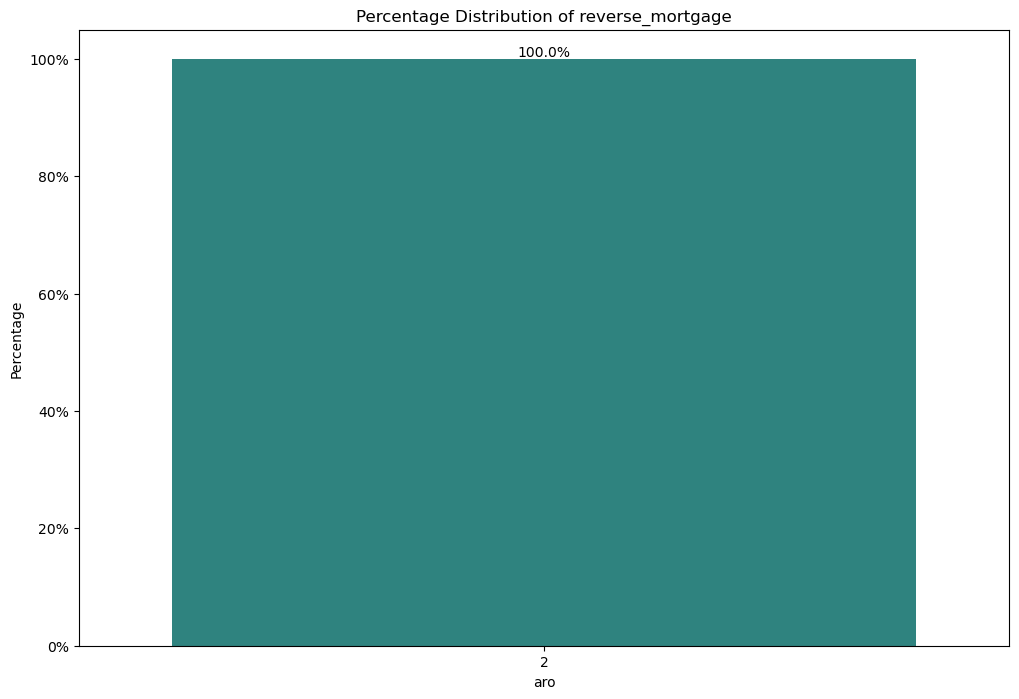

In [152]:
# column and dataset
data = hmda_ohe_all['reverse_mortgage']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['reverse_mortgage'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='reverse_mortgage', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of reverse_mortgage")
plt.ylabel("Percentage")
plt.xlabel("aro")
plt.show()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\1188361196.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='applicant_race_observed', y="Percentage", data=pct_df, palette="viridis", legend=False)


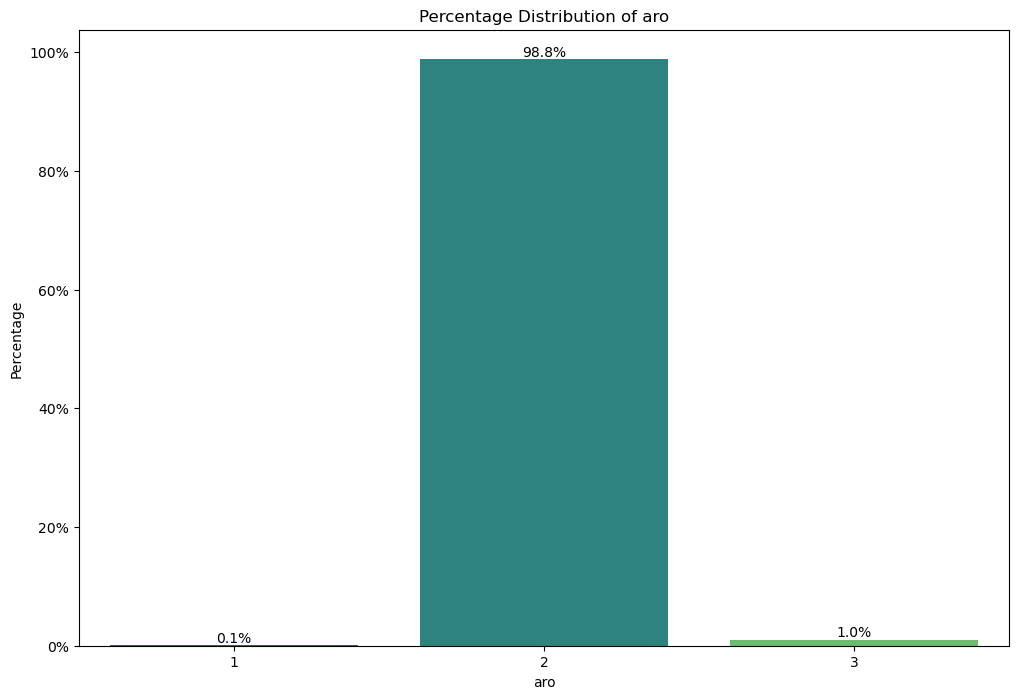

In [153]:
# column and dataset
data = hmda_ohe_all['applicant_race_observed']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['applicant_race_observed'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='applicant_race_observed', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of aro")
plt.ylabel("Percentage")
plt.xlabel("aro")
plt.show()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\4168989182.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='other_nonamortizing_features', y="Percentage", data=pct_df, palette="viridis", legend=False)


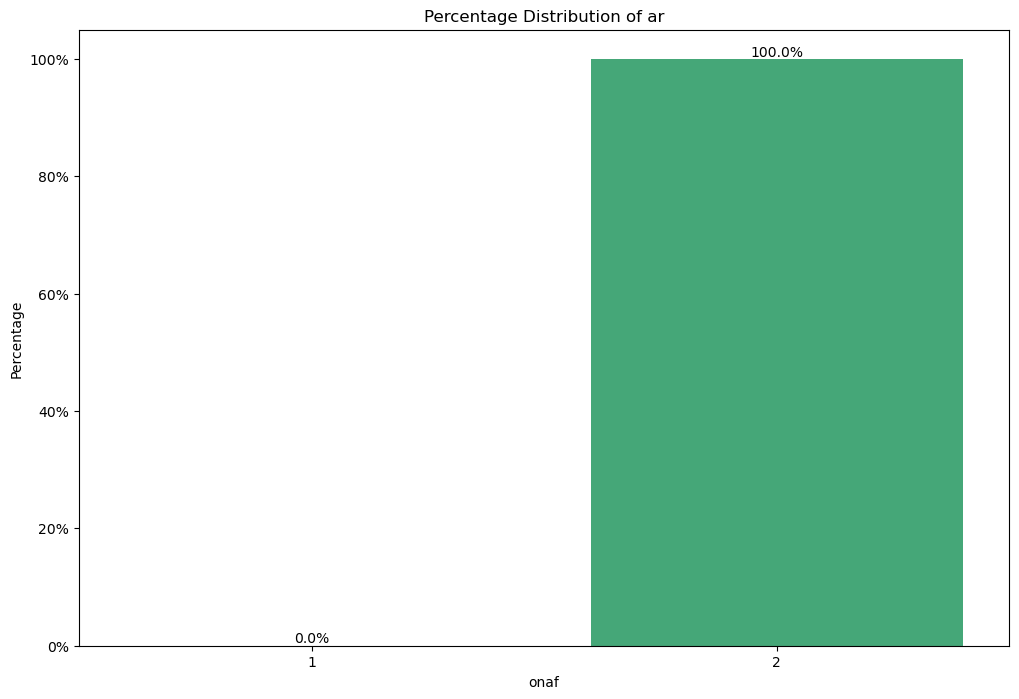

In [154]:
# column and dataset
data = hmda_ohe_all['other_nonamortizing_features']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['other_nonamortizing_features'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='other_nonamortizing_features', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("onaf")
plt.show()

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2537209916.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='balloon_payment', y="Percentage", data=pct_df, palette="viridis", legend=False)


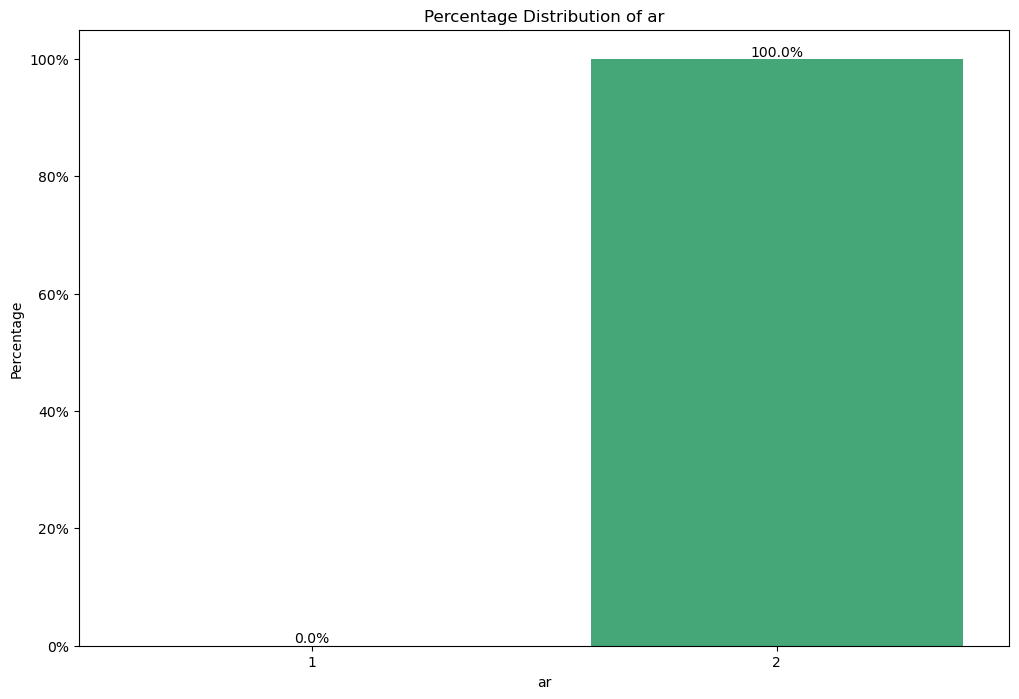

In [155]:
# column and dataset
data = hmda_ohe_all['balloon_payment']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['balloon_payment'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='balloon_payment', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("ar")
plt.show()



In [156]:
# applicant_race-1
# Description: Race of the applicant or borrower
# Values:
# 1 - American Indian or Alaska Native
# 2 - Asian
# 21 - Asian Indian
# 22 - Chinese
# 23 - Filipino
# 24 - Japanese
# 25 - Korean
# 26 - Vietnamese
# 27 - Other Asian
# 3 - Black or African American
# 4 - Native Hawaiian or Other Pacific Islander
# 41 - Native Hawaiian
# 42 - Guamanian or Chamorro
# 43 - Samoan
# 44 - Other Pacific Islander
# 5 - White
# 6 - Information not provided by applicant in mail, internet, or telephone application
# 7 - Not applicable

list_of_values_to_keep = [1, 2, 3, 4, 21, 22, 23, 24, 25, 26, 27, 41, 42, 43, 44]

hmda_ohe_dr_ar1test = hmda_ohe_all[hmda_ohe_all['applicant_race-1'].isin(list_of_values_to_keep)]
hmda_ohe_dr_ar1test['applicant_race-1'].unique()

array([ 3.,  2., 23., 25.,  1., 26.,  4., 21., 24., 27., 22., 43., 44.,
       42.])

C:\Users\Cat\AppData\Local\Temp\ipykernel_5016\2738253754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='applicant_race-1', y="Percentage", data=pct_df, palette="viridis", legend=False)


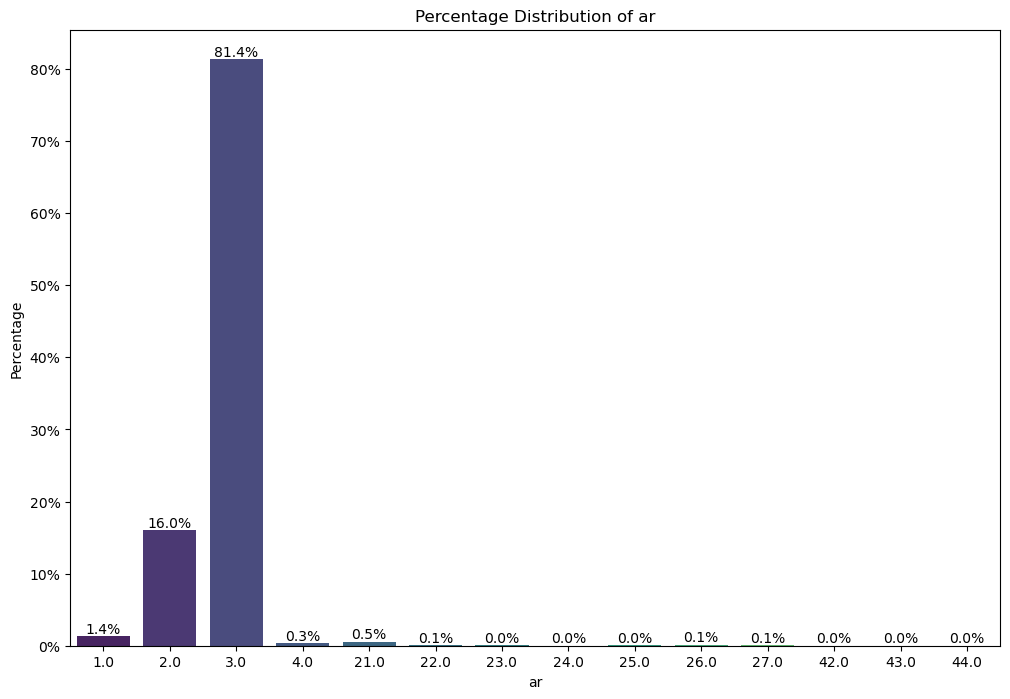

In [157]:
# column and dataset
data = hmda_ohe_dr_ar1test['applicant_race-1']
df = hmda_ohe_dr_ar1test

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['applicant_race-1'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='applicant_race-1', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("ar")
plt.show()



### Applicant Ethnicity

In [158]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_3 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14""", data=hmda_ohe_all)

In [159]:
res_ae = model_logit_ae.fit()

Optimization terminated successfully.
         Current function value: 0.540320
         Iterations 5


In [160]:
res_ae.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                30489
Model:                                     Logit   Df Residuals:                    30482
Method:                                      MLE   Df Model:                            6
Date:                           Sat, 27 Jun 2026   Pseudo R-squ.:               0.0008122
Time:                                   11:01:25   Log-Likelihood:                -16474.
converged:                                  True   LL-Null:                       -16487.
Covariance Type:                       nonrobust   LLR p-value:                 0.0001592
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.2369      0.016     75.335      0.000       1.205       1.269
ae_values_1      0.1970      0.098      2.003      0.045       0.004       0.390
ae_values_3     -0.1365      0.031     -4.400      0.000      -0.197      -0.076
ae_values_11    -0.1426      0.159     -0.898      0.369      -0.454       0.169
ae_values_12    -0.2014      0.190     -1.059      0.290      -0.574       0.171
ae_values_13    -0.2239      0.290     -0.772      0.440      -0.792       0.344
ae_values_14    -0.3064      0.118     -2.590      0.010      -0.538      -0.075
================================================================================
"""